# Analise Exploratoria (EDA)
Este notebook consolida os principais KPIs, regioes, assessorias e comportamentos financeiros encontrados nas bases limpas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

contratos = pd.read_csv('contratos_clean.csv')
pagamentos = pd.read_csv('pagamentos_clean.csv', parse_dates=['Data_Vencimento', 'Data_Pagamento'])

## KPIs oficiais da analise

In [2]:
ref_date = pagamentos['Data_Vencimento'].max()
parcelas_vencidas = pagamentos[pagamentos['Data_Vencimento'] <= ref_date]
parcelas_abertas = parcelas_vencidas[parcelas_vencidas['Data_Pagamento'].isna()]
pagamentos_atrasados = pagamentos[
    pagamentos['Data_Pagamento'].notna()
    & (pagamentos['Data_Pagamento'] > pagamentos['Data_Vencimento'])
]

valor_inadimplente_contratos = contratos['Valor_Inadimplente_Inicial'].sum()
inadimplencia_monitorada_parcelas = parcelas_abertas['Valor_Parcela'].sum()
taxa_inadimplencia_parcelas = len(parcelas_abertas) / len(parcelas_vencidas) * 100
taxa_recuperacao_pagamentos = len(pagamentos_atrasados) / len(parcelas_vencidas) * 100
valor_recuperado_atrasado = pagamentos_atrasados['Valor_Pago'].sum()
atraso_inicial_medio = contratos['Dias_Em_Atraso_Inicial'].mean()
aging_operacional = (ref_date - parcelas_abertas['Data_Vencimento']).dt.days.mean()
taxa_acordo_contratos = contratos['Status_Cobranca'].eq('Acordo Firmado').mean() * 100

kpis = pd.DataFrame([
    ['Valor inadimplente dos contratos', valor_inadimplente_contratos],
    ['Inadimplencia monitorada em parcelas abertas', inadimplencia_monitorada_parcelas],
    ['Taxa de inadimplencia em parcelas', taxa_inadimplencia_parcelas],
    ['Taxa de recuperacao por pagamentos atrasados', taxa_recuperacao_pagamentos],
    ['Valor pago em parcelas recuperadas com atraso', valor_recuperado_atrasado],
    ['Atraso medio inicial dos contratos', atraso_inicial_medio],
    ['Aging operacional das parcelas abertas', aging_operacional],
    ['Taxa de acordo firmado em contratos', taxa_acordo_contratos],
], columns=['KPI', 'Valor'])

print(f'Data de referencia da base: {ref_date.date()}')
print(kpis.to_string(index=False))

Data de referencia da base: 2026-03-26
                                          KPI        Valor
             Valor inadimplente dos contratos 6.230884e+07
 Inadimplencia monitorada em parcelas abertas 2.062140e+07
            Taxa de inadimplencia em parcelas 2.735700e+01
 Taxa de recuperacao por pagamentos atrasados 2.549800e+01
Valor pago em parcelas recuperadas com atraso 1.989356e+07
           Atraso medio inicial dos contratos 8.964570e+01
       Aging operacional das parcelas abertas 2.238638e+02
          Taxa de acordo firmado em contratos 3.407000e+01


## Inadimplencia regional

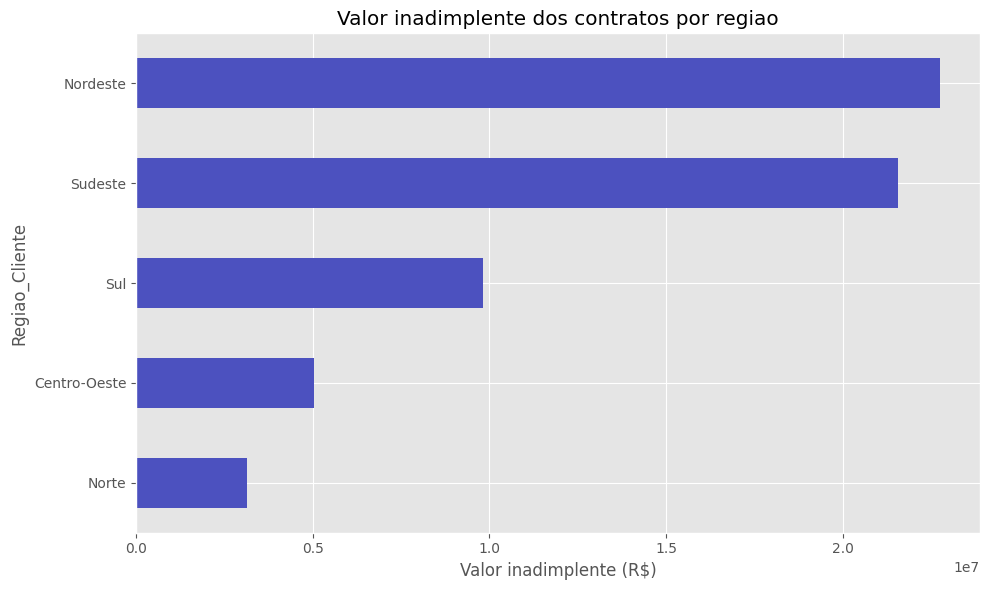

Regiao_Cliente
Nordeste        22748368.22
Sudeste         21556882.87
Sul              9828722.06
Centro-Oeste     5026348.66
Norte            3148518.99
Name: Valor_Inadimplente_Inicial, dtype: float64


In [3]:
inad_regional_contratos = contratos.groupby('Regiao_Cliente')['Valor_Inadimplente_Inicial'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
inad_regional_contratos.sort_values().plot(kind='barh', color='#4c51bf')
plt.title('Valor inadimplente dos contratos por regiao')
plt.xlabel('Valor inadimplente (R$)')
plt.tight_layout()
plt.show()

print(inad_regional_contratos.round(2))

## Tendencia temporal de pagamentos

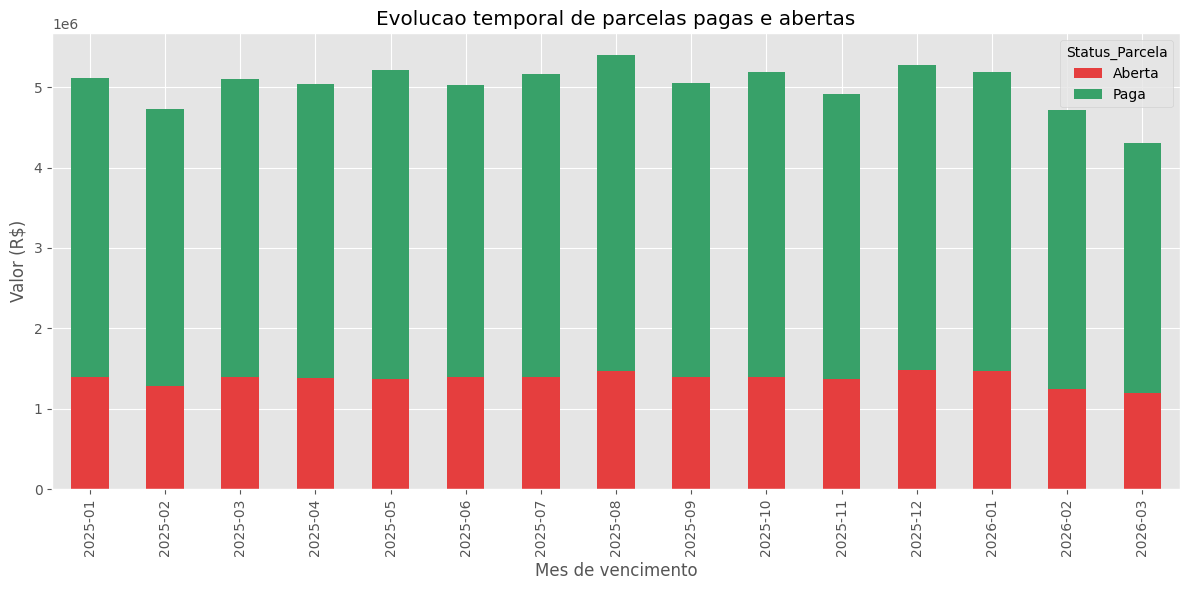

Status_Parcela   Aberta     Paga
Mes_Vencimento                  
2025-10         1398650  3792400
2025-11         1371600  3540450
2025-12         1476600  3800200
2026-01         1472600  3718400
2026-02         1248800  3470000
2026-03         1196600  3103800


In [4]:
pagamentos['Mes_Vencimento'] = pagamentos['Data_Vencimento'].dt.to_period('M')
pagamentos['Status_Parcela'] = pagamentos['Data_Pagamento'].notna().map({True: 'Paga', False: 'Aberta'})
evolucao = pagamentos.groupby(['Mes_Vencimento', 'Status_Parcela'])['Valor_Parcela'].sum().unstack().fillna(0)

evolucao.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#e53e3e', '#38a169'])
plt.title('Evolucao temporal de parcelas pagas e abertas')
plt.xlabel('Mes de vencimento')
plt.ylabel('Valor (R$)')
plt.tight_layout()
plt.show()

print(evolucao.tail(6).round(2))

## Desempenho das assessorias

In [5]:
assessorias = contratos.groupby('Nome_Assessoria').agg(
    contratos=('ID_Contrato', 'count'),
    acordos=('Status_Cobranca', lambda s: (s == 'Acordo Firmado').sum()),
    insucessos=('Status_Cobranca', lambda s: (s == 'Insucesso').sum()),
    ajuizados=('Status_Cobranca', lambda s: (s == 'Ajuizado').sum()),
    valor_total=('Valor_Inadimplente_Inicial', 'sum'),
)
assessorias['taxa_acordo_pct'] = assessorias['acordos'] / assessorias['contratos'] * 100
assessorias['taxa_insucesso_pct'] = assessorias['insucessos'] / assessorias['contratos'] * 100
assessorias = assessorias.sort_values('taxa_acordo_pct', ascending=False)

print(assessorias.round(2))

                              contratos  acordos  insucessos  ajuizados  \
Nome_Assessoria                                                           
Acerta Credito Integrado           1926      675         295        202   
Nexus Mediacao Financeira          2037      696         292        194   
Vertice Asset e Cobranca           3003     1022         468        326   
Fenix Recuperacao de Credito       3034     1014         494        308   

                              valor_total  taxa_acordo_pct  taxa_insucesso_pct  
Nome_Assessoria                                                                 
Acerta Credito Integrado      12031471.12            35.05               15.32  
Nexus Mediacao Financeira     12847846.25            34.17               14.33  
Vertice Asset e Cobranca      18723629.75            34.03               15.58  
Fenix Recuperacao de Credito  18705893.68            33.42               16.28  
